# 8-Class Semiconductor Defect Detection
## Combined Synthetic + Real Dataset Training

**Classes**: bridge, clean, cmp_scratch, crack, film_residue, ler, other, particles

**Data Sources**:
- Synthetic: Bridge, LER, Other, Particles (train/val/test folders)
- Real: All 8 classes (train/vald/test folders)

## 1. Setup & Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# GPU configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Available: {len(gpus)} device(s)")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️  No GPU detected, using CPU")

print(f"✅ TensorFlow version: {tf.__version__}")


⚠️  No GPU detected, using CPU
✅ TensorFlow version: 2.15.0


## 2. Configuration

In [2]:
# Paths
DATASET_ROOT = r"c:\Mugi\Projects\IISE\AI model\Dataset"
OUTPUT_DIR = r"c:\Mugi\Projects\IISE\AI model\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 8 Classes (standardized lowercase)
CLASS_NAMES = ['bridge', 'clean', 'cmp_scratch', 'crack', 'film_residue', 'ler', 'other', 'particles']
NUM_CLASSES = len(CLASS_NAMES)

# Model config
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training config
INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 20
INITIAL_LR = 0.001
FINE_TUNE_LR = 0.0001

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"Dataset root: {DATASET_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nClasses ({NUM_CLASSES}): {', '.join(CLASS_NAMES)}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print("="*70)

CONFIGURATION
Dataset root: c:\Mugi\Projects\IISE\AI model\Dataset
Output directory: c:\Mugi\Projects\IISE\AI model\outputs

Classes (8): bridge, clean, cmp_scratch, crack, film_residue, ler, other, particles
Image size: (224, 224)
Batch size: 32


## 3. Data Loading from Multiple Sources

In [3]:
def load_images_from_folder(folder_path, class_idx, img_size=IMG_SIZE):
    """Load all images from a folder."""
    images, labels = [], []
    folder = Path(folder_path)
    
    if not folder.exists():
        return images, labels
    
    # Get all image files
    image_files = []
    for ext in ['*.png', '*.PNG', '*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.bmp', '*.BMP']:
        image_files.extend(list(folder.glob(ext)))
    
    for img_path in image_files:
        try:
            img = keras.preprocessing.image.load_img(str(img_path), target_size=img_size, color_mode='grayscale')
            img_array = keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(class_idx)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    return images, labels

# Data sources mapping
data_sources = {
    'bridge': {
        'train': [
            os.path.join(DATASET_ROOT, 'Bridge', 'train'),
            os.path.join(DATASET_ROOT, 'train', 'bridge')
        ],
        'val': [
            os.path.join(DATASET_ROOT, 'Bridge', 'val'),
            os.path.join(DATASET_ROOT, 'vald', 'bridge'),
            os.path.join(DATASET_ROOT, 'validation_dataset', 'bridge')
        ],
        'test': [
            os.path.join(DATASET_ROOT, 'Bridge', 'test'),
            os.path.join(DATASET_ROOT, 'test', 'bridge')
        ]
    },
    'clean': {
        'train': [os.path.join(DATASET_ROOT, 'train', 'clean')],
        'val': [
            os.path.join(DATASET_ROOT, 'vald', 'clean'),
            os.path.join(DATASET_ROOT, 'validation_dataset', 'clean')
        ],
        'test': [os.path.join(DATASET_ROOT, 'test', 'clean')]
    },
    'cmp_scratch': {
        'train': [os.path.join(DATASET_ROOT, 'train', 'cmp_scratch')],
        'val': [
            os.path.join(DATASET_ROOT, 'vald', 'cmp_scratch'),
            os.path.join(DATASET_ROOT, 'validation_dataset', 'cmp_scratch')
        ],
        'test': [os.path.join(DATASET_ROOT, 'test', 'cmp_scratch')]
    },
    'crack': {
        'train': [
            os.path.join(DATASET_ROOT, 'train', 'crack'),
            os.path.join(DATASET_ROOT, 'train', 'cracks')
        ],
        'val': [
            os.path.join(DATASET_ROOT, 'vald', 'crack'),
            os.path.join(DATASET_ROOT, 'vald', 'cracks'),
            os.path.join(DATASET_ROOT, 'validation_dataset', 'crack')
        ],
        'test': [
            os.path.join(DATASET_ROOT, 'test', 'crack'),
            os.path.join(DATASET_ROOT, 'test', 'cracks')
        ]
    },
    'film_residue': {
        'train': [os.path.join(DATASET_ROOT, 'train', 'film_residue')],
        'val': [
            os.path.join(DATASET_ROOT, 'vald', 'film_residue'),
            os.path.join(DATASET_ROOT, 'validation_dataset', 'film_residue')
        ],
        'test': [os.path.join(DATASET_ROOT, 'test', 'film_residue')]
    },
    'ler': {
        'train': [os.path.join(DATASET_ROOT, 'LER', 'train')],
        'val': [os.path.join(DATASET_ROOT, 'LER', 'val')],
        'test': [os.path.join(DATASET_ROOT, 'LER', 'test')]
    },
    'other': {
        'train': [os.path.join(DATASET_ROOT, 'Other', 'train')],
        'val': [os.path.join(DATASET_ROOT, 'Other', 'val')],
        'test': [os.path.join(DATASET_ROOT, 'Other', 'test')]
    },
    'particles': {
        'train': [
            os.path.join(DATASET_ROOT, 'Particles', 'train'),
            os.path.join(DATASET_ROOT, 'train', 'particles')
        ],
        'val': [
            os.path.join(DATASET_ROOT, 'Particles', 'val'),
            os.path.join(DATASET_ROOT, 'vald', 'particles'),
            os.path.join(DATASET_ROOT, 'validation_dataset', 'particles')
        ],
        'test': [
            os.path.join(DATASET_ROOT, 'Particles', 'test'),
            os.path.join(DATASET_ROOT, 'test', 'particles')
        ]
    }
}

# Load data
print("\n" + "="*70)
print("LOADING DATASET")
print("="*70)

train_images, train_labels = [], []
val_images, val_labels = [], []
test_images, test_labels = [], []

for class_idx, class_name in enumerate(CLASS_NAMES):
    print(f"\n{class_name.upper()}:")
    
    # Train
    for folder in data_sources[class_name]['train']:
        imgs, lbls = load_images_from_folder(folder, class_idx)
        if len(imgs) > 0:
            train_images.extend(imgs)
            train_labels.extend(lbls)
            print(f"  TRAIN: {len(imgs):4d} from {Path(folder).name}")
    
    # Val
    for folder in data_sources[class_name]['val']:
        imgs, lbls = load_images_from_folder(folder, class_idx)
        if len(imgs) > 0:
            val_images.extend(imgs)
            val_labels.extend(lbls)
            print(f"  VAL:   {len(imgs):4d} from {Path(folder).name}")
    
    # Test
    for folder in data_sources[class_name]['test']:
        imgs, lbls = load_images_from_folder(folder, class_idx)
        if len(imgs) > 0:
            test_images.extend(imgs)
            test_labels.extend(lbls)
            print(f"  TEST:  {len(imgs):4d} from {Path(folder).name}")

# Convert to arrays
X_train = np.array(train_images) / 255.0
y_train = keras.utils.to_categorical(train_labels, num_classes=NUM_CLASSES)

X_val = np.array(val_images) / 255.0
y_val = keras.utils.to_categorical(val_labels, num_classes=NUM_CLASSES)

X_test = np.array(test_images) / 255.0
y_test = keras.utils.to_categorical(test_labels, num_classes=NUM_CLASSES)

# Summary
print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Training:   {X_train.shape[0]:4d} images")
print(f"Validation: {X_val.shape[0]:4d} images")
print(f"Test:       {X_test.shape[0]:4d} images")
print(f"Total:      {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:4d} images")

print(f"\n{'Class':<15} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-"*70)
for i, name in enumerate(CLASS_NAMES):
    t = sum(1 for x in train_labels if x == i)
    v = sum(1 for x in val_labels if x == i)
    te = sum(1 for x in test_labels if x == i)
    print(f"{name:<15} {t:>8} {v:>8} {te:>8} {t+v+te:>8}")
print("="*70)


LOADING DATASET

BRIDGE:
  TRAIN:  840 from train
  VAL:    180 from val
  VAL:     20 from bridge
  TEST:   180 from test

CLEAN:
  VAL:     20 from clean

CMP_SCRATCH:
  VAL:     20 from cmp_scratch

CRACK:
  VAL:     20 from crack

FILM_RESIDUE:
  VAL:     20 from film_residue

LER:
  TRAIN:  840 from train
  VAL:    180 from val
  TEST:   180 from test

OTHER:
  TRAIN:  840 from train
  VAL:    180 from val
  TEST:   180 from test

PARTICLES:
  TRAIN:  840 from train
  VAL:    180 from val
  VAL:     20 from particles
  TEST:   180 from test

DATASET SUMMARY
Training:   3360 images
Validation:  840 images
Test:        720 images
Total:      4920 images

Class              Train      Val     Test    Total
----------------------------------------------------------------------
bridge               840      200      180     1220
clean                  0       20        0       20
cmp_scratch            0       20        0       20
crack                  0       20        0       20
fi

## 4. Visualize Samples

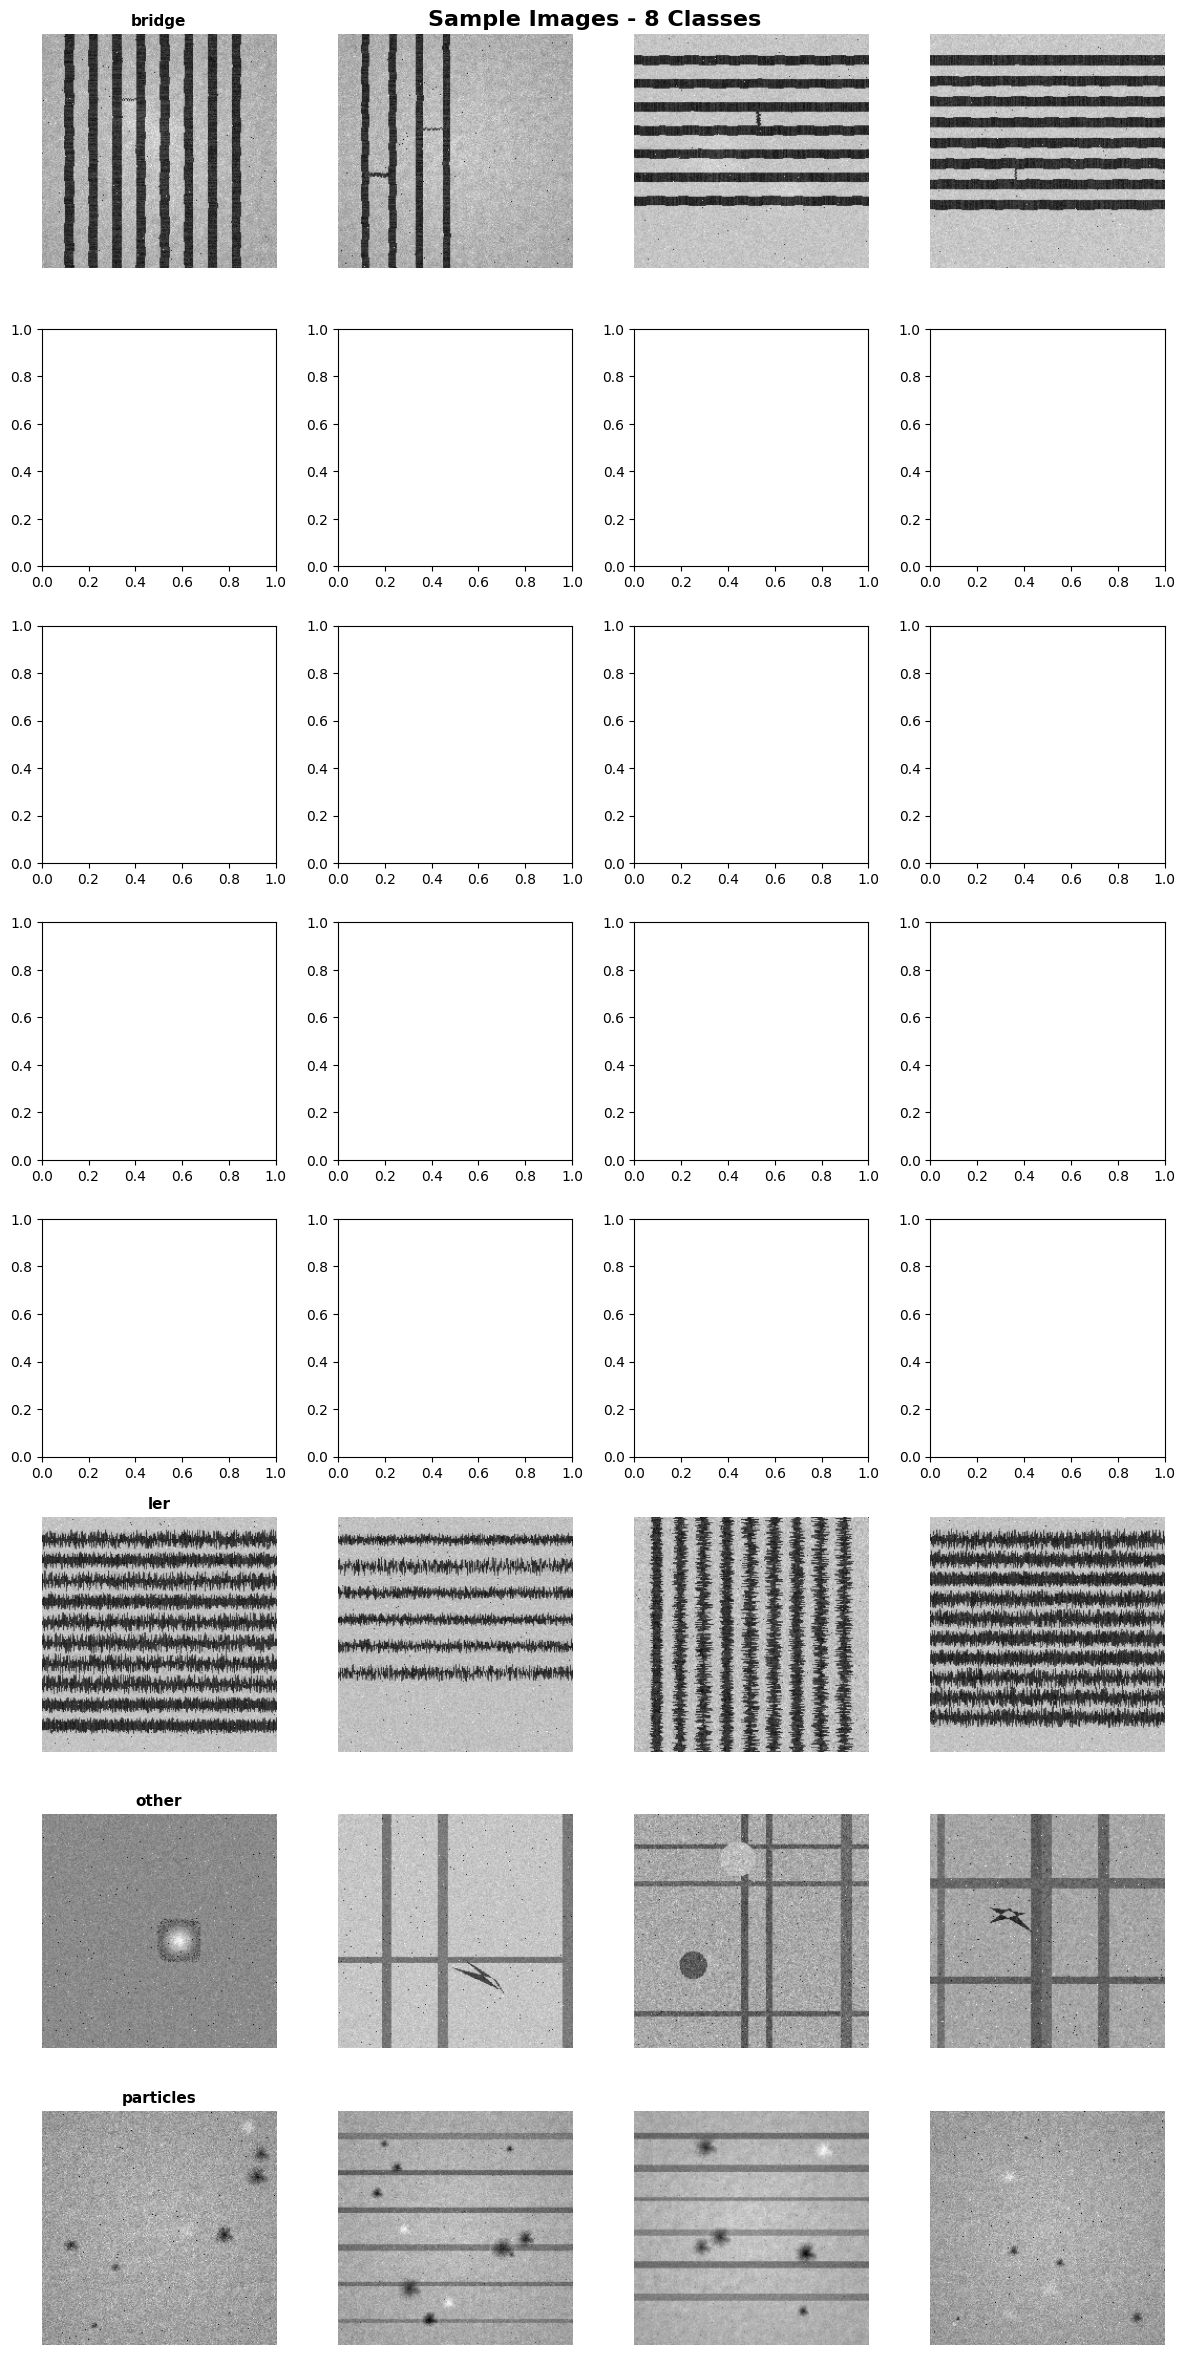

✅ Samples saved


In [4]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 3*NUM_CLASSES))
fig.suptitle(f'Sample Images - {NUM_CLASSES} Classes', fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASS_NAMES):
    indices = [i for i, x in enumerate(train_labels) if x == class_idx]
    if len(indices) > 0:
        samples = np.random.choice(indices, min(4, len(indices)), replace=False)
        for i, idx in enumerate(samples):
            axes[class_idx, i].imshow(X_train[idx].squeeze(), cmap='gray')
            axes[class_idx, i].axis('off')
            if i == 0:
                axes[class_idx, i].set_title(class_name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'samples_8class.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Samples saved")

## 5. Build Model

In [5]:
def build_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    inputs = layers.Input(shape=(*img_size, 1))
    x = layers.Concatenate()([inputs, inputs, inputs])  # Grayscale to RGB
    
    base_model = MobileNetV3Small(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False
    
    x = base_model(x, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs), base_model

model, base_model = build_model()
print(f"Total parameters: {model.count_params():,}")
model.summary()



Total parameters: 1,122,296
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 1)]        0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 224, 224, 3)          0         ['input_1[0][0]',             
                                                                     'input_1[0][0]',             
                                                                     'input_1[0][0]']             
                                                                                                  
 MobilenetV3small (Function  (None, 576)                  939120    ['concatenate[0][0]']         
 al)                                                            

## 6. Phase 1: Train Classifier Head

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

callbacks_p1 = [
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'phase1_best.h5'), monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

print("\nPHASE 1: Training classifier head (base frozen)")
history_p1 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=INITIAL_EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_p1, verbose=1)
print("✅ Phase 1 complete")


PHASE 1: Training classifier head (base frozen)
Epoch 1/5


105/105 [==============================] - ETA: 0s - loss: 1.6682 - accuracy: 0.4220 - precision: 0.5907 - recall: 0.2315
Epoch 1: val_accuracy improved from -inf to 0.57143, saving model to c:\Mugi\Projects\IISE\AI model\outputs\phase1_best.h5


c:\anaconda\envs\iesa\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


105/105 [==============================] - 16s 118ms/step - loss: 1.6682 - accuracy: 0.4220 - precision: 0.5907 - recall: 0.2315 - val_loss: 1.3839 - val_accuracy: 0.5714 - val_precision: 1.0000 - val_recall: 0.0310 - lr: 0.0010
Epoch 2/5
105/105 [==============================] - ETA: 0s - loss: 0.8950 - accuracy: 0.6164 - precision: 0.6852 - recall: 0.5196
Epoch 2: val_accuracy improved from 0.57143 to 0.60238, saving model to c:\Mugi\Projects\IISE\AI model\outputs\phase1_best.h5
105/105 [==============================] - 11s 102ms/step - loss: 0.8950 - accuracy: 0.6164 - precision: 0.6852 - recall: 0.5196 - val_loss: 1.0811 - val_accuracy: 0.6024 - val_precision: 0.6522 - val_recall: 0.4286 - lr: 0.0010
Epoch 3/5
105/105 [==============================] - ETA: 0s - loss: 0.6721 - accuracy: 0.6714 - precision: 0.7029 - recall: 0.6196
Epoch 3: val_accuracy improved from 0.60238 to 0.61429, saving model to c:\Mugi\Projects\IISE\AI model\outputs\phase1_best.h5
105/105 [=================

## 7. Phase 2: Fine-Tune Entire Model

In [7]:
base_model.trainable = True
model.compile(
    optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

callbacks_p2 = [
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_model_8class.h5'), monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    TensorBoard(log_dir=os.path.join(OUTPUT_DIR, 'logs'))
]

print("\nPHASE 2: Fine-tuning entire model")
history_p2 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=FINE_TUNE_EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_p2, verbose=1)

model.save(os.path.join(OUTPUT_DIR, 'final_model_8class.h5'))
print("✅ Phase 2 complete, model saved")


PHASE 2: Fine-tuning entire model
Epoch 1/20
105/105 [==============================] - ETA: 0s - loss: 0.5170 - accuracy: 0.7545 - precision_1: 0.7727 - recall_1: 0.7253
Epoch 1: val_accuracy improved from -inf to 0.61429, saving model to c:\Mugi\Projects\IISE\AI model\outputs\best_model_8class.h5
105/105 [==============================] - 45s 353ms/step - loss: 0.5170 - accuracy: 0.7545 - precision_1: 0.7727 - recall_1: 0.7253 - val_loss: 1.5713 - val_accuracy: 0.6143 - val_precision_1: 0.6272 - val_recall_1: 0.6048 - lr: 1.0000e-04
Epoch 2/20
105/105 [==============================] - ETA: 0s - loss: 0.4045 - accuracy: 0.7753 - precision_1: 0.7905 - recall_1: 0.7557
Epoch 2: val_accuracy did not improve from 0.61429
105/105 [==============================] - 41s 392ms/step - loss: 0.4045 - accuracy: 0.7753 - precision_1: 0.7905 - recall_1: 0.7557 - val_loss: 1.8236 - val_accuracy: 0.5524 - val_precision_1: 0.5447 - val_recall_1: 0.4929 - lr: 1.0000e-04
Epoch 3/20
105/105 [=========

## 8. Training History

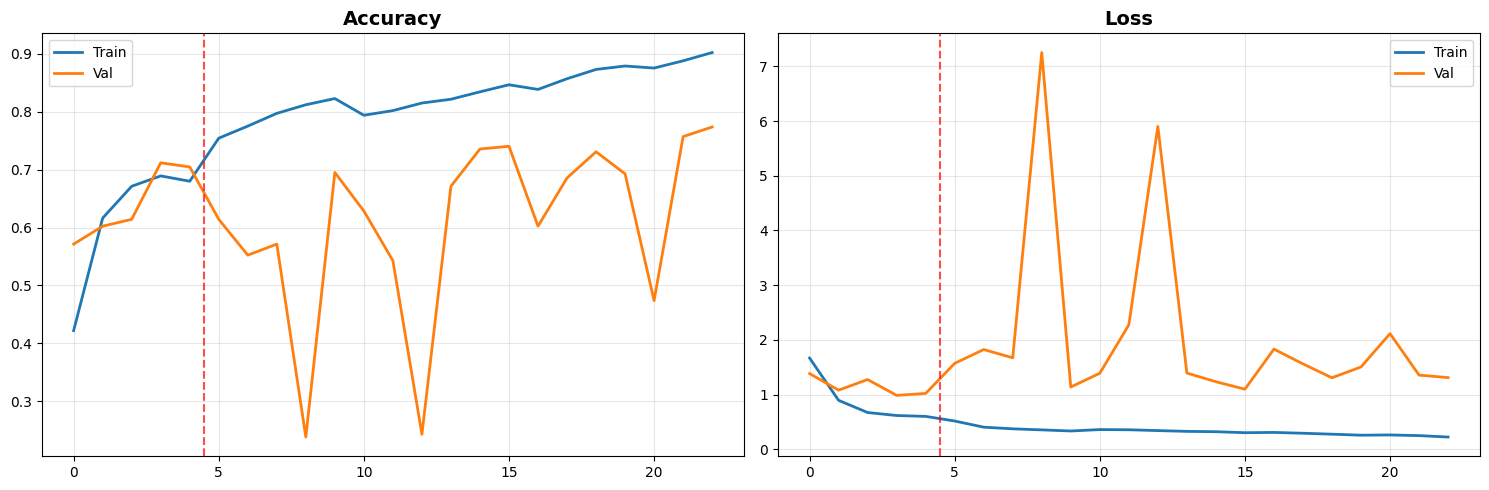

✅ History saved


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

ax1.plot(acc, label='Train', linewidth=2)
ax1.plot(val_acc, label='Val', linewidth=2)
ax1.axvline(INITIAL_EPOCHS-0.5, color='red', linestyle='--', alpha=0.7)
ax1.set_title('Accuracy', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(loss, label='Train', linewidth=2)
ax2.plot(val_loss, label='Val', linewidth=2)
ax2.axvline(INITIAL_EPOCHS-0.5, color='red', linestyle='--', alpha=0.7)
ax2.set_title('Loss', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'history_8class.png'), dpi=150)
plt.show()
print("✅ History saved")

## 9. Evaluate on Test Set

In [9]:
best_model = keras.models.load_model(os.path.join(OUTPUT_DIR, 'best_model_8class.h5'))

test_loss, test_acc, test_prec, test_rec = best_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {2*(test_prec*test_rec)/(test_prec+test_rec):.4f}")
print("="*70)

23/23 [==============================] - 3s 86ms/step - loss: 0.2306 - accuracy: 0.8778 - precision_1: 0.8778 - recall_1: 0.8778

TEST RESULTS
Accuracy:  0.8778 (87.78%)
Precision: 0.8778
Recall:    0.8778
F1-Score:  0.8778


## 10. Confusion Matrix

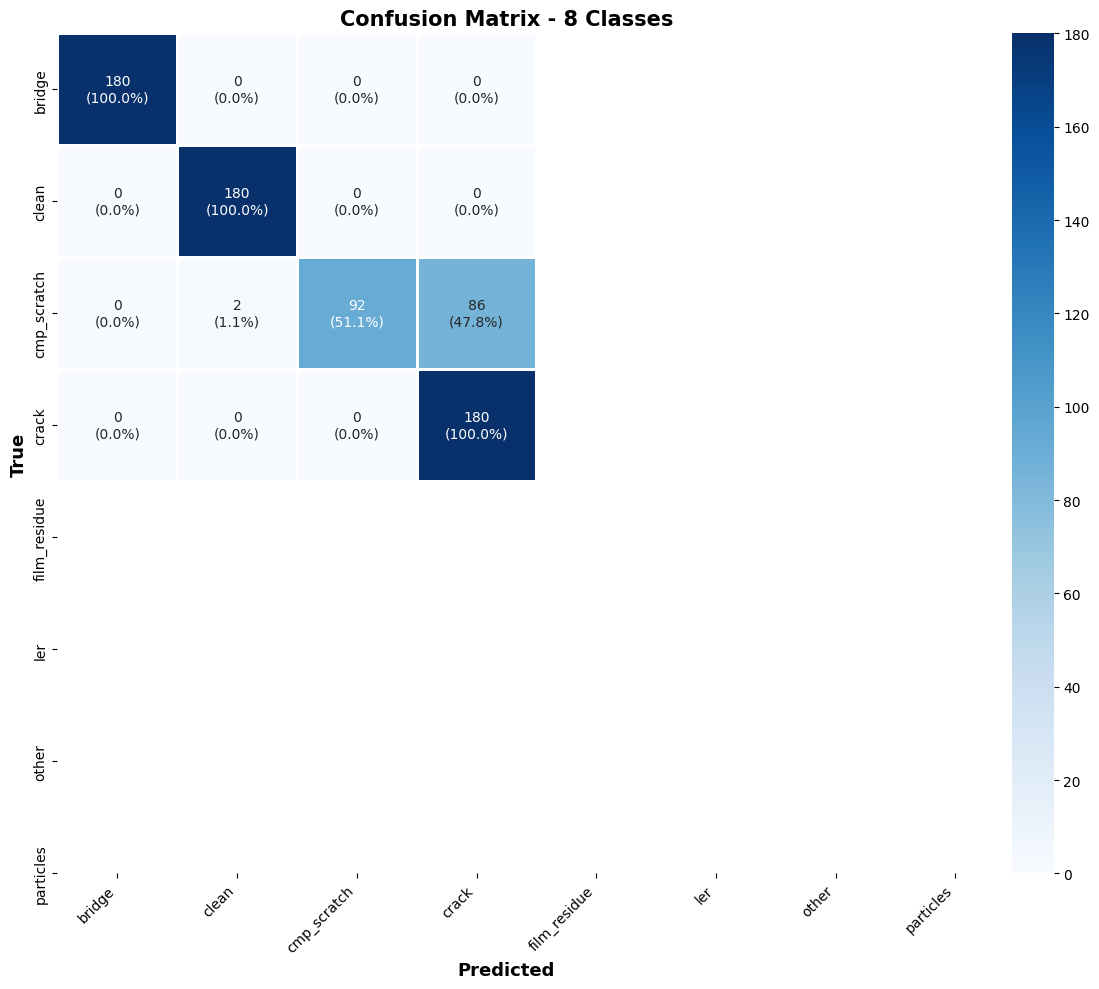

✅ Confusion matrix saved


In [10]:
y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i,j] = f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=1, ax=ax)
ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax.set_ylabel('True', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix - 8 Classes', fontsize=15, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_8class.png'), dpi=200)
plt.show()
print("✅ Confusion matrix saved")

## 11. Classification Report

In [ ]:
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print("="*70)

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
with open(os.path.join(OUTPUT_DIR, 'report_8class.json'), 'w') as f:
    json.dump(report, f, indent=2)
print("✅ Report saved")

## 12. Export to TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, 'model_8class.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

h5_size = os.path.getsize(os.path.join(OUTPUT_DIR, 'best_model_8class.h5')) / (1024*1024)
tflite_size = os.path.getsize(tflite_path) / (1024*1024)

print(f"\nKeras:  {h5_size:.2f} MB")
print(f"TFLite: {tflite_size:.2f} MB ({(1-tflite_size/h5_size)*100:.1f}% reduction)")
print(f"✅ TFLite model saved to {tflite_path}")

## 13. Summary

In [ ]:
summary = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'classes': CLASS_NAMES,
        'train': X_train.shape[0],
        'val': X_val.shape[0],
        'test': X_test.shape[0],
        'total': X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
    },
    'performance': {
        'accuracy': float(test_acc),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'f1': float(2*(test_prec*test_rec)/(test_prec+test_rec))
    }
}

with open(os.path.join(OUTPUT_DIR, 'summary_8class.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*70)
print("TRAINING COMPLETE - 8 CLASS DEFECT DETECTION")
print("="*70)
print(f"Total images: {summary['dataset']['total']}")
print(f"Test accuracy: {summary['performance']['accuracy']:.4f} ({summary['performance']['accuracy']*100:.2f}%)")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print("="*70)
print("\n🚀 Model ready for deployment!")